In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
# 2.Dataset loading
df=pd.read_csv("tesla_deliveries_dataset_2015_2025[1].csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
# 3.Dataset Overview
print("Shape:",df.shape)
df.info()
df.describe()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [5]:
# 4.Data preprocessing
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates()

Duplicates: 0


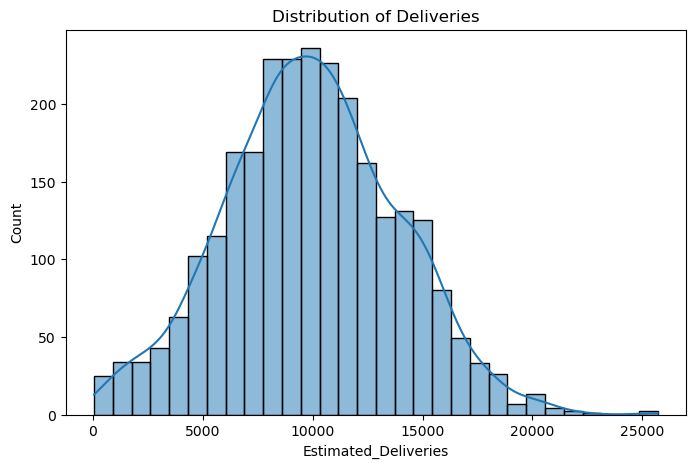

In [6]:
# 5. Exploratory Data Analysis (EDA)
#Deliveries distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)

plt.title("Distribution of Deliveries")
plt.show()

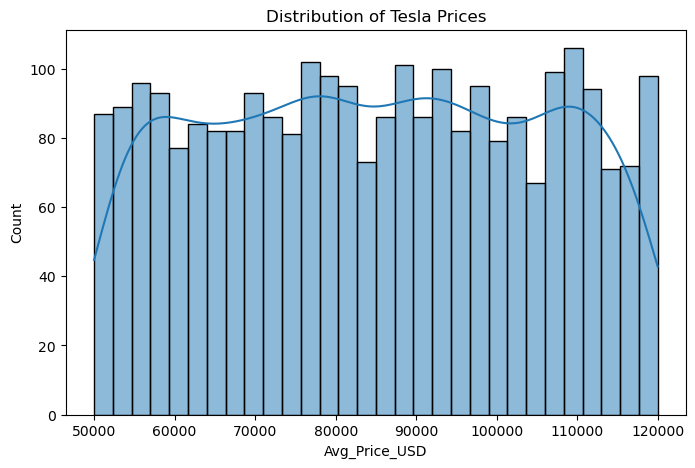

In [7]:
#Average Price Distribution 
plt.figure(figsize=(8,5))

sns.histplot(df['Avg_Price_USD'],
             bins=30,
             kde=True)

plt.title("Distribution of Tesla Prices")
plt.show()

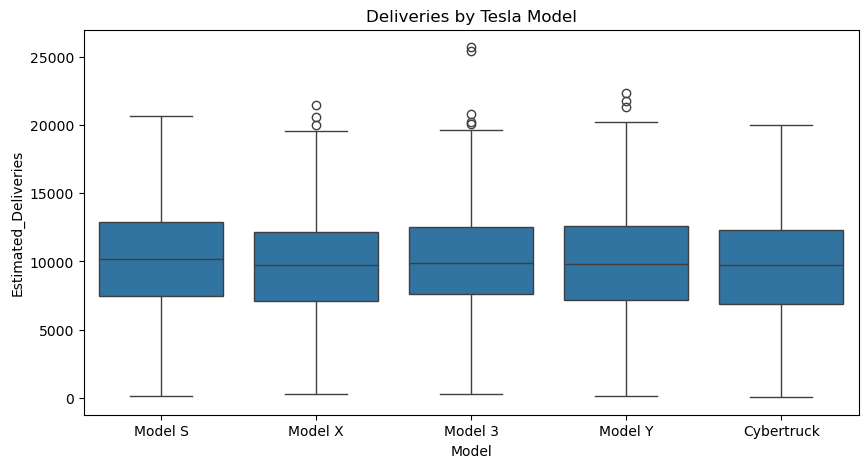

In [8]:
#Deliveries by Vehicle model
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Model",
    y="Estimated_Deliveries",
    data=df
)

plt.title("Deliveries by Tesla Model")
plt.show()

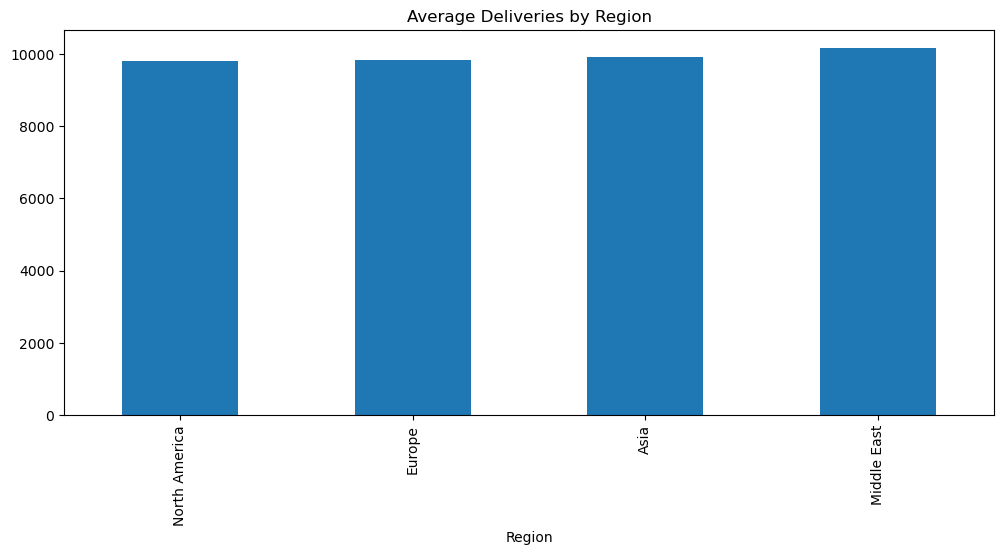

In [9]:
#Deliveries by region
plt.figure(figsize=(12,5))

region_sales = df.groupby("Region")["Estimated_Deliveries"].mean()

region_sales.sort_values().plot(kind="bar")

plt.title("Average Deliveries by Region")
plt.show()

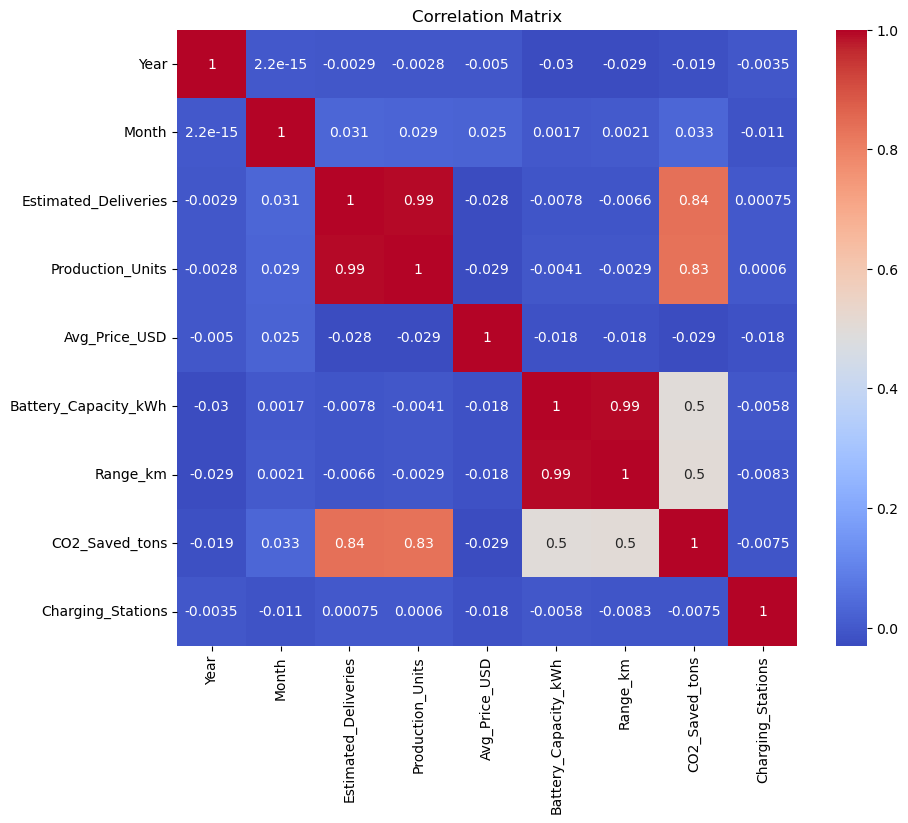

In [10]:
#Correlation Heatmap
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [12]:
# 6. Feature Engineering

# create date features
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

#Delivery efficiency
df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries']
    / df['Production_Units']
)

#Price per Km
df["Price_per_Km"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

#Encode Categorical variables
label_cols = ['Region', 'Model', 'Source_Type']

encoder = LabelEncoder()

for col in label_cols:
    df[col] = encoder.fit_transform(df[col])

In [13]:
# 7. Regression Model

# feature selection
X = df.drop(
    columns=[
        'Estimated_Deliveries',
        'Date'
    ]
)

y = df['Estimated_Deliveries']

In [14]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# 8. Baseline model
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [16]:
# Evaluation
print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_lr)))

print("R2 Score:",
      r2_score(y_test, pred_lr))

Linear Regression Results
MAE: 108.88658400197407
RMSE: 153.3342321928072
R2 Score: 0.998422720227123


In [17]:
# 9. Random Forest Regression
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [18]:
# Evaluation
print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test, pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_rf)))

print("R2 Score:",
      r2_score(y_test, pred_rf))

Random Forest Results
MAE: 67.465321969697
RMSE: 111.97049052280099
R2 Score: 0.9991589193342192


In [19]:
# 10. Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

In [20]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [21]:
# best parameters
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}


In [22]:
# Best Model
best_rf = grid.best_estimator_

pred_best = best_rf.predict(X_test)

In [23]:
print("Tuned Random Forest")

print("MAE:",
      mean_absolute_error(y_test, pred_best))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_best)))

print("R2 Score:",
      r2_score(y_test, pred_best))

Tuned Random Forest
MAE: 67.44565991762867
RMSE: 111.73898866495598
R2 Score: 0.9991623936505336


In [24]:
# 11. Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

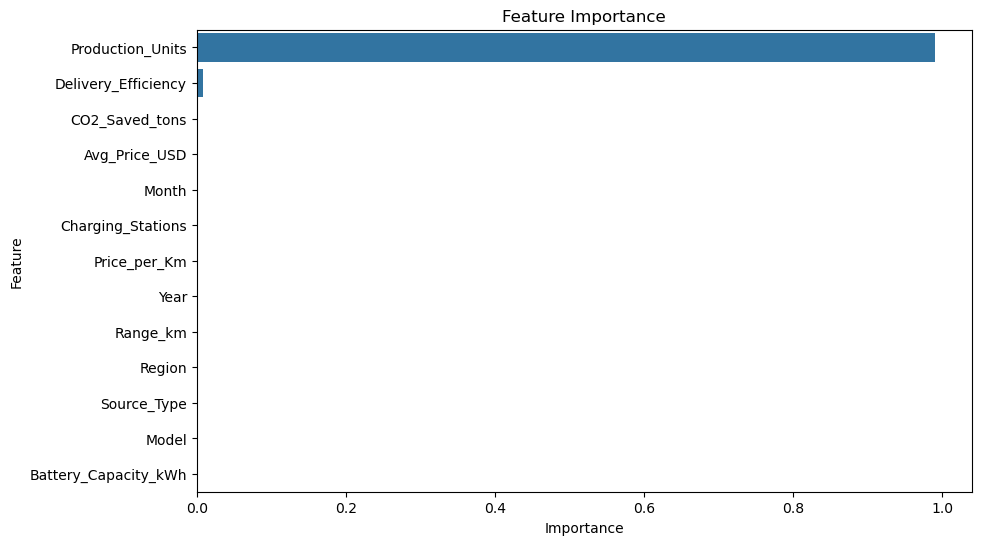

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [26]:
# 12. Time Series Forecasting

# Monthly Deliveries Trend
ts = df.groupby('Date')[
    'Estimated_Deliveries'
].sum()

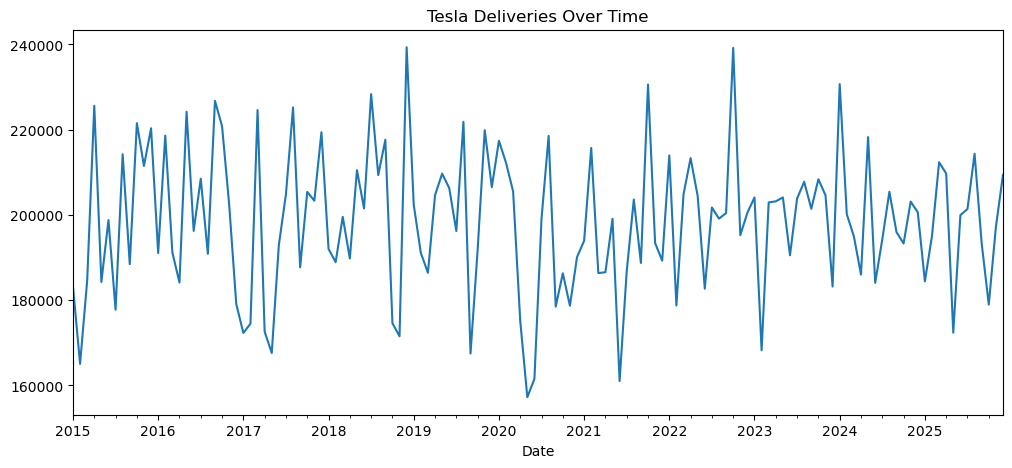

In [27]:
plt.figure(figsize=(12,5))

ts.plot()

plt.title("Tesla Deliveries Over Time")

plt.show()

In [33]:
# Train Forecasting Model
model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit_model = model.fit()

C:\new anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\new anaconda\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [29]:
# Forecast of Next 12 Months
forecast = fit_model.forecast(12)

In [30]:
forecast

2026-01-01    193768.363081
2026-02-01    190224.357024
2026-03-01    197784.740716
2026-04-01    189825.506374
2026-05-01    196273.797440
2026-06-01    190535.488925
2026-07-01    200163.103541
2026-08-01    207505.745284
2026-09-01    196905.825612
2026-10-01    202197.103921
2026-11-01    195279.466999
2026-12-01    204994.105661
Freq: MS, dtype: float64

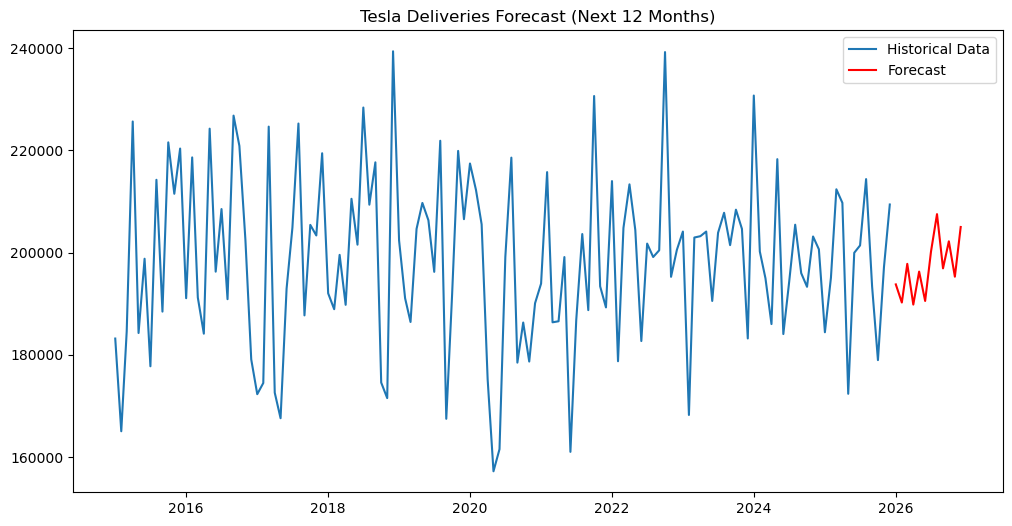

In [31]:
# Visualization
plt.figure(figsize=(12,6))

plt.plot(
    ts.index,
    ts.values,
    label='Historical Data'
)

plt.plot(
    forecast.index,
    forecast.values,
    label='Forecast',
    color='red'
)

plt.legend()

plt.title(
    "Tesla Deliveries Forecast (Next 12 Months)"
)

plt.show()

In [32]:
# 13. Final Conclusion
print("""
PROJECT SUMMARY

1. Performed data preprocessing and cleaning.
2. Conducted exploratory data analysis.
3. Created engineered features:
   - Delivery Efficiency
   - Price per KM
4. Built Linear Regression and Random Forest models.
5. Improved performance using GridSearchCV.
6. Analyzed feature importance.
7. Forecasted future Tesla deliveries using Time Series Analysis.

Result:
Random Forest delivered the best predictive performance,
while Exponential Smoothing successfully forecasted
future delivery trends.
""")


PROJECT SUMMARY

1. Performed data preprocessing and cleaning.
2. Conducted exploratory data analysis.
3. Created engineered features:
   - Delivery Efficiency
   - Price per KM
4. Built Linear Regression and Random Forest models.
5. Improved performance using GridSearchCV.
6. Analyzed feature importance.
7. Forecasted future Tesla deliveries using Time Series Analysis.

Result:
Random Forest delivered the best predictive performance,
while Exponential Smoothing successfully forecasted
future delivery trends.

